# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Formativa 2 aplicadas no programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos. No entanto, o presente relatório busca analisar somente os dados de 30 turmas provenientes de aditivo de contrato. Segue lista de código de turmas a serem analisadas aqui:

TURMA-P0000009-0002; 
TURMA-P0000135-0001; 
TURMA-P0000004-0002; 
TURMA-P0000026-0002; 
TURMA-28000013-0007; 
TURMA-28000013-0008; 
TURMA-28009398-0018; 
TURMA-28018389-0012; 
TURMA-P0000136-0001; 
TURMA-28018575-0017; 
TURMA-28023315-0010; 
TURMA-28021177-0005; 
TURMA-28029577-0010; 
TURMA-28003047-0001; 
TURMA-28020553-0001; 
TURMA-28014170-0001; 
TURMA-28014170-0002; 
TURMA-28003624-0001; 
TURMA-28003365-0005; 
TURMA-28003411-0001; 
TURMA-28003411-0002; 
TURMA-28009983-0008; 
TURMA-28009983-0009; 
TURMA-28007409-0001; 
TURMA-28029372-0003; 
TURMA-28029372-0004; 
TURMA-28007360-0003; 
TURMA-28030451-0001; 
TURMA-28003500-0007; 
TURMA-28003500-0008.


## Importando bibliotecas e dados

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib import patheffects
import seaborn as sns
import os
import geopandas as gpd
import contextily as ctx
import textwrap
from statistics import mode, median, StatisticsError
import numpy as np
from scipy.stats import chi2_contingency, wilcoxon

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_23102025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_23102025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_23102025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagnostica_23102025.xlsx')
df_relatorios_formativa1 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa1_23102025.xlsx')
df_relatorios_formativa2 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa2_23102025.xlsx')
df_relatorios_formativa3 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa3_23102025.xlsx')
df_relatorios_formativa4 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa4_23102025.xlsx')
df_relatorios_somativa = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_somativa_23102025.xlsx')

print('df_cadastro:')
print(df_cadastro.info())
#print(df_cadastro.head())

print('df_turmas:')
print(df_turmas.info())
#print(df_turmas.head())

print('df_registros:')
print(df_registros.info())
#print(df_registros.head())

print('df_relatorios_diagnostica:')
print(df_relatorios_diagnostica.info())
#print(df_relatorios_diagnostica.head())

print('df_relatorios_formativa1:')
print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa1.head())

print('df_relatorios_formativa2:')
print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa2.head())

print('df_relatorios_formativa3:')
print(df_relatorios_formativa3.info())
#print(df_relatorios_formativa3.head())

print('df_relatorios_formativa4:')
print(df_relatorios_formativa4.info())
#print(df_relatorios_formativa4.head())

print('df_relatorios_somativa:')
print(df_relatorios_somativa.info())
#print(df_relatorios_somativa.head())


df_cadastro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4621 entries, 0 to 4620
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   CPF                        4621 non-null   object
 1   Nome                       4621 non-null   object
 2   Turma                      4621 non-null   object
 3   Data de início             4621 non-null   object
 4   Alfabetizador              4621 non-null   object
 5   Coordenador                4621 non-null   object
 6   Qtde presença              4621 non-null   int64 
 7   Qtde ausência              4621 non-null   int64 
 8   Atividade - Entrada        4614 non-null   object
 9   Atividade - Formativa 1    4614 non-null   object
 10  Atividade - Formativa 2    4591 non-null   object
 11  Atividade - Formativa 3    3904 non-null   object
 12  Atividade - Formativa 4    3506 non-null   object
 13  Atividade - Saída          3347 non-null   object


## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui.

Em df_cadastro, df_turmas, df_relatorios_(diagnostica / formativa1, 2 e 3):
- Todas as colunas que contem datas deverão ser tranformados para o tipo datetime.

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_formativa1.columns = [to_snake_case(col) for col in df_relatorios_formativa1.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Padronizando pergunta em df_relatorios_formativa1
df_relatorios_formativa1 = df_relatorios_formativa1.rename(columns={'quais_os_possiveis_entraves_ocorridos_para_o_desenvolvimento_da_turma?':'entraves_no_desenvolvimento_da_turma'})

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_registros.info())
#print(df_relatorios_formativa1.info())


### Extração das turmas do aditivo a serem analisadas
Antes de iniciar as análises, vamos extrair somente os dados das 30 turmas que precisamos e descartar todo o resto.

In [3]:
# Lista das turmas que você quer filtrar
turmas_selecionadas = [
    "TURMA-P0000009-0002", "TURMA-P0000135-0001", "TURMA-P0000004-0002", "TURMA-P0000026-0002",
    "TURMA-28000013-0007", "TURMA-28000013-0008", "TURMA-28009398-0018", "TURMA-28018389-0012",
    "TURMA-P0000136-0001", "TURMA-28018575-0017", "TURMA-28023315-0010", "TURMA-28021177-0005",
    "TURMA-28029577-0010", "TURMA-28003047-0001", "TURMA-28020553-0001", "TURMA-28014170-0001",
    "TURMA-28014170-0002", "TURMA-28003624-0001", "TURMA-28003365-0005", "TURMA-28003411-0001",
    "TURMA-28003411-0002", "TURMA-28009983-0008", "TURMA-28009983-0009", "TURMA-28007409-0001",
    "TURMA-28029372-0003", "TURMA-28029372-0004", "TURMA-28007360-0003", "TURMA-28030451-0001",
    "TURMA-28003500-0007", "TURMA-28003500-0008"
]

# Função para filtrar turmas
def filtrar_turmas(df, coluna_turma='turma'):
    """
    Filtra um dataframe para manter apenas as linhas com as turmas selecionadas.
    
    Parâmetros:
    df -- DataFrame a ser filtrado
    coluna_turma -- nome da coluna que contém os códigos das turmas (padrão: 'turma')
    
    Retorna:
    DataFrame filtrado apenas com as turmas selecionadas
    """
    # Verifica se a coluna existe no dataframe
    if coluna_turma not in df.columns:
        raise ValueError(f"A coluna '{coluna_turma}' não foi encontrada no DataFrame")
    
    # Filtra o dataframe
    df_filtrado = df[df[coluna_turma].isin(turmas_selecionadas)]
    
    return df_filtrado

# Aplicando função
df_cadastro = filtrar_turmas(df_cadastro, coluna_turma='turma')
df_turmas = filtrar_turmas(df_turmas, coluna_turma='turma')
df_registros = filtrar_turmas(df_registros, coluna_turma='turma')
df_relatorios_formativa1 = filtrar_turmas(df_relatorios_formativa1, coluna_turma='turma')

# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA']


## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender quantas turmas estão estudando cada unidade do livro (1, 2, 3 ou 4), no estado todo e por município.
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Fazer comparativos para entender evolução dos alunos, comparando Formativas em suas devidas Práticas de Linguagem, no estado e em cada município;
- Entender se está havendo evolução ou não dos alunos. 

In [4]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_turmas['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Entendendo número de turmas com registros de formativa 3
turmas_com_registros_formativa2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']['turma'].nunique()

# Impirmindo resultados
print(f"Número total de alunos estudando: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")
print(f"Número de turmas com registros de formativa 2: {turmas_com_registros_formativa2}")


Número total de alunos estudando: 553
Número total de turmas iniciadas: 30
Número médio de alunos por turma: 18.43
Número de turmas com registros de formativa 2: 29


In [5]:
# Entendendo número de registros em cada turma para Formativa 3
contagem_por_turma = df_cadastro.groupby('turma')['atividade_-_formativa_2'].count()

# Listando turmas sem dados
sem_dados = contagem_por_turma[contagem_por_turma == 0].index.tolist()
com_dados = contagem_por_turma[contagem_por_turma > 0].index.tolist()

# Imprimindo resultados
print(f"Número de turmas com dados de formativa 2:{len(com_dados)}")
print(f"Número de turmas sem dados de formativa 2:{len(sem_dados)}")
print()
print(f"Turmas sem dados de formativa 2:{sem_dados}")
print()
print(contagem_por_turma)


Número de turmas com dados de formativa 2:29
Número de turmas sem dados de formativa 2:1

Turmas sem dados de formativa 2:['TURMA-P0000009-0002']

turma
TURMA-28000013-0007    18
TURMA-28000013-0008    14
TURMA-28003047-0001    14
TURMA-28003365-0005    19
TURMA-28003411-0001    24
TURMA-28003411-0002    16
TURMA-28003500-0007    25
TURMA-28003500-0008    13
TURMA-28003624-0001    18
TURMA-28007360-0003    18
TURMA-28007409-0001    21
TURMA-28009398-0018    21
TURMA-28009983-0008    17
TURMA-28009983-0009    19
TURMA-28014170-0001    15
TURMA-28014170-0002    14
TURMA-28018389-0012    22
TURMA-28018575-0017    16
TURMA-28020553-0001    23
TURMA-28021177-0005    17
TURMA-28023315-0010    24
TURMA-28029372-0003    20
TURMA-28029372-0004    19
TURMA-28029577-0010    11
TURMA-28030451-0001    10
TURMA-P0000004-0002    21
TURMA-P0000009-0002     0
TURMA-P0000026-0002    25
TURMA-P0000135-0001    13
TURMA-P0000136-0001    19
Name: atividade_-_formativa_2, dtype: int64


In [6]:
# Retirando os dados da turma que não possui registros de formativa 2 (TURMA-P0000009-0002)
df_cadastro = df_cadastro[df_cadastro['turma'] != 'TURMA-P0000009-0002']
df_turmas = df_turmas[df_turmas['turma'] != 'TURMA-P0000009-0002']
df_registros = df_registros[df_registros['turma'] != 'TURMA-P0000009-0002']
df_relatorios_formativa1 = df_relatorios_formativa1[df_relatorios_formativa1['turma'] != 'TURMA-P0000009-0002']
df_registros_diag = df_registros_diag[df_registros_diag['turma'] != 'TURMA-P0000009-0002']
df_registros_form_1 = df_registros_form_1[df_registros_form_1['turma'] != 'TURMA-P0000009-0002']
df_registros_form_2 = df_registros_form_2[df_registros_form_2['turma'] != 'TURMA-P0000009-0002']
df_registros_form_3 = df_registros_form_3[df_registros_form_3['turma'] != 'TURMA-P0000009-0002']
df_registros_form_4 = df_registros_form_4[df_registros_form_4['turma'] != 'TURMA-P0000009-0002']
df_registros_soma = df_registros_soma[df_registros_soma['turma'] != 'TURMA-P0000009-0002']

In [7]:
# Find values in cadastro that are not in registros
only_in_cadastro = set(df_cadastro['turma']) - set(df_registros['turma'])

# Find values in registros that are not in cadastro
only_in_registros = set(df_registros['turma']) - set(df_cadastro['turma'])

print("Values only in df_cadastro['turma']:", only_in_cadastro)
print("Values only in df_registros['turma']:", only_in_registros)

Values only in df_cadastro['turma']: set()
Values only in df_registros['turma']: set()


In [8]:
# Pegando a lista de municipios das turmas selecionadas
municipios_turmas = sorted(df_turmas['municipio'].unique())
print(municipios_turmas)

['ARACAJU', 'CANINDÉ DE SÃO FRANCISCO', 'CAPELA', 'CARIRA', 'ITABAIANA', 'ITABAIANINHA', 'NOSSA SENHORA DO SOCORRO', 'PORTO DA FOLHA', 'SALGADO', 'SIMÃO DIAS', 'SÃO CRISTÓVÃO']


Vamos a quantidade de turmas que estão estudando cada unidade no presente momento no programa como um todo e por município.

In [9]:
# Primeiro, vamos criar um dicionário com a ordem hierárquica das atividades
ordem_atividades = {
    'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n': 6,
    'ATIVIDADE ESTRUTURADA FORMATIVA 4': 5,
    'ATIVIDADE ESTRUTURADA FORMATIVA 3': 4,
    'ATIVIDADE ESTRUTURADA FORMATIVA 2': 3,
    'ATIVIDADE ESTRUTURADA FORMATIVA 1': 2,
    'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA': 1
}

# Para cada turma, encontramos a atividade mais avançada que ela realizou
turmas_atividades = df_registros.groupby('turma')['atividade'].apply(
    lambda x: max(x.unique(), key=lambda a: ordem_atividades.get(a, 0))
).reset_index()

# Agora classificamos as turmas conforme sua atividade mais avançada
ls_turmas_finalizadas = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']['turma'])
ls_turmas_somativa = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']['turma'])
ls_turmas_unid_4 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']['turma'])
ls_turmas_unid_3 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']['turma'])
ls_turmas_unid_2 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']['turma'])
ls_turmas_unid_1 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']['turma'])

# Verificação - todas as turmas devem estar em exatamente uma lista
total_turmas_classificadas = (len(ls_turmas_finalizadas) + len(ls_turmas_somativa) + len(ls_turmas_unid_4) + 
                            len(ls_turmas_unid_3) + len(ls_turmas_unid_2) + len(ls_turmas_unid_1))
print(f"Total de turmas classificadas: {total_turmas_classificadas}")
print(f"Total de turmas no dataframe: {df_registros['turma'].nunique()}")

Total de turmas classificadas: 29
Total de turmas no dataframe: 29


In [10]:
# Criamos o DataFrame base com todos os municípios únicos
turmas_por_unidade = pd.DataFrame(df_registros['municipio'].unique(), columns=['municipio'])

# Função auxiliar para contar turmas e garantir todos municípios
def contar_turmas(df, turmas, nome_coluna):
    contagem = (df[df['turma'].isin(turmas)]
               .groupby('municipio')['turma']
               .nunique()
               .reset_index()
               .rename(columns={'turma': nome_coluna}))
    
    # Fazemos o merge mantendo todos os municípios originais
    resultado = pd.merge(turmas_por_unidade, contagem, on='municipio', how='left')
    resultado[nome_coluna] = resultado[nome_coluna].fillna(0).astype('int64')
    return resultado

# Aplicamos para cada lista de turmas
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_1, 'turmas_em_unid_1')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_2, 'turmas_em_unid_2')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_3, 'turmas_em_unid_3')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_4, 'turmas_em_unid_4')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_somativa, 'turmas_em_somativa')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_finalizadas, 'turmas_finalizadas')
turmas_por_unidade = turmas_por_unidade.sort_values(by='municipio', ascending=True).reset_index(drop=True)


# Entendendo quantidade de turmas por município
turmas_por_unidade['total_turmas'] = turmas_por_unidade[['turmas_em_unid_1', 'turmas_em_unid_2', 
                                                       'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas']].sum(axis=1)

print(f'Checando total de turmas: {turmas_por_unidade['total_turmas'].sum()}')
turmas_por_unidade


Checando total de turmas: 29


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,turmas_finalizadas,total_turmas
0,Aracaju,0,0,3,0,0,0,3
1,Canindé de São Francisco,0,0,3,0,0,0,3
2,Capela,0,0,2,0,0,0,2
3,Carira,0,0,1,0,0,0,1
4,Itabaiana,0,0,3,0,0,0,3
5,Itabaianinha,0,0,1,0,0,0,1
6,Nossa Senhora do Socorro,0,0,1,0,0,0,1
7,Porto da Folha,0,0,7,2,0,0,9
8,Salgado,0,0,1,0,0,0,1
9,Simão Dias,0,0,3,0,0,0,3


/tmp/ipykernel_65199/1590041208.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),


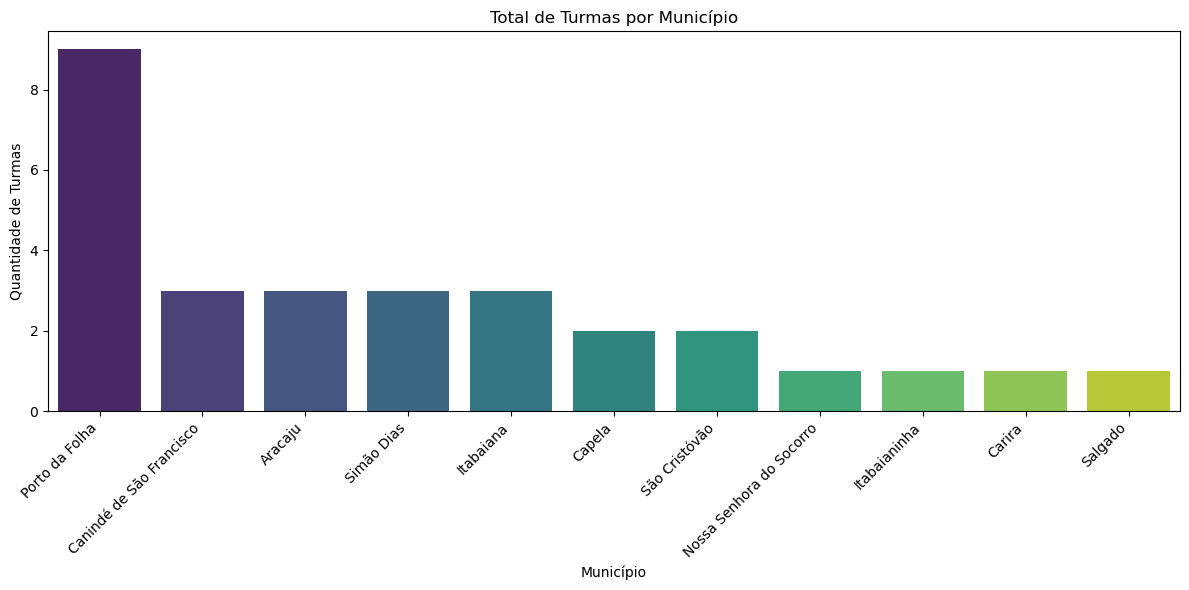

In [11]:
# Criando diretório para salvar os gráficos
output_dir_relatorio_22 = "Data_files/graficos_relatorio_2.2_turmas_aditivo"
os.makedirs(output_dir_relatorio_22, exist_ok=True)

# Criando gráfico de total de turmas por município
plt.figure(figsize=(12, 6))
sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),
            x='municipio', y='total_turmas', palette='viridis')
plt.title('Total de Turmas por Município')
plt.xlabel('Município')
plt.ylabel('Quantidade de Turmas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_dir_relatorio_22}/total_por_municipio.png', dpi=300)
plt.show()

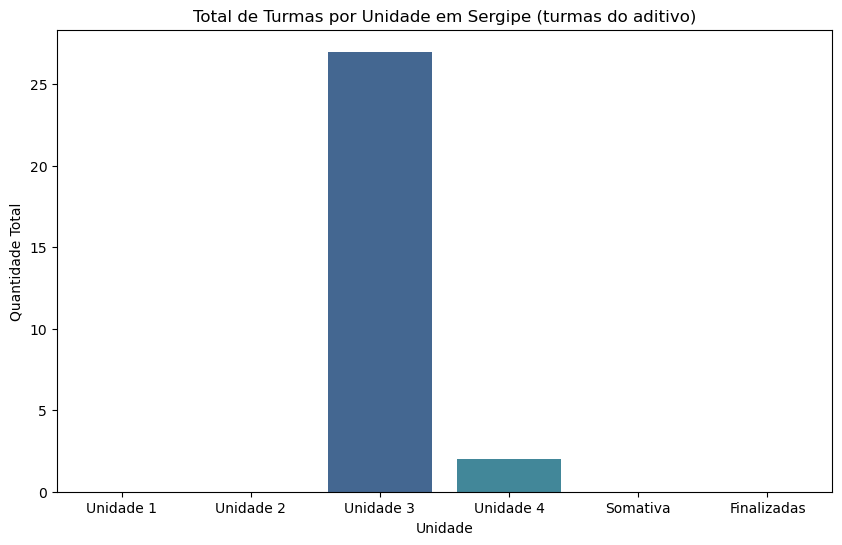

Total de turmas contabilizadas: 29


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,turmas_finalizadas,total_turmas
0,Aracaju,0,0,3,0,0,0,3
1,Canindé de São Francisco,0,0,3,0,0,0,3
2,Capela,0,0,2,0,0,0,2
3,Carira,0,0,1,0,0,0,1
4,Itabaiana,0,0,3,0,0,0,3
5,Itabaianinha,0,0,1,0,0,0,1
6,Nossa Senhora do Socorro,0,0,1,0,0,0,1
7,Porto da Folha,0,0,7,2,0,0,9
8,Salgado,0,0,1,0,0,0,1
9,Simão Dias,0,0,3,0,0,0,3


In [12]:
# Criando gráfico de total de turmas em cada unidade
# Gráfico 2: Total de turmas por unidade (com rótulos personalizados)
df_unidades = turmas_por_unidade.melt(
    id_vars=['municipio'],
    value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
    var_name='Unidade',
    value_name='Quantidade'
)

# Mapear nomes das unidades
mapeamento_unidades = {
    'turmas_em_unid_1': 'Unidade 1',
    'turmas_em_unid_2': 'Unidade 2',
    'turmas_em_unid_3': 'Unidade 3',
    'turmas_em_unid_4': 'Unidade 4',
    'turmas_em_somativa': 'Somativa',
    'turmas_finalizadas': 'Finalizadas'
}
df_unidades['Unidade'] = df_unidades['Unidade'].map(mapeamento_unidades)

# Plotar o gráfico (sem warnings!)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_unidades,
    x='Unidade',
    y='Quantidade',
    hue='Unidade',      # Adicionado para evitar o warning
    estimator=sum,
    errorbar=None,
    palette='mako',
    legend=False        # Remove legenda redundante
)
plt.title('Total de Turmas por Unidade em Sergipe (turmas do aditivo)')
plt.xlabel('Unidade')
plt.ylabel('Quantidade Total')
plt.savefig(f'{output_dir_relatorio_22}/total_turmas_por_unidade_sergipe.png', dpi=300)
#plt.close()
plt.show()

print(f"Total de turmas contabilizadas: {turmas_por_unidade['total_turmas'].sum()}")

turmas_por_unidade

In [13]:
# Criando um gráfico por município para mostrar número de turmas em cada unidade
# Criar um gráfico para cada município
for municipio in turmas_por_unidade['municipio'].unique():
    # Filtrar dados do município
    df_municipio = turmas_por_unidade[turmas_por_unidade['municipio'] == municipio]
    
    # Transformar os dados para formato longo (melt) e aplicar mapeamento
    df_melted = df_municipio.melt(
        id_vars=['municipio'], 
        value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
        var_name='Unidade', 
        value_name='Quantidade'
    )
    
    # Aplicar os novos nomes das unidades
    df_melted['Unidade'] = df_melted['Unidade'].map(mapeamento_unidades)
    
    # Ordenar as unidades
    df_melted['Unidade'] = pd.Categorical(
        df_melted['Unidade'],
        categories=['Unidade 1', 'Unidade 2', 'Unidade 3', 'Unidade 4', 'Somativa', 'Finalizadas'],
        ordered=True
    )
    
    # Configurar o gráfico (versão atualizada do Seaborn)
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_melted,
        x='Unidade',
        y='Quantidade',
        hue='Unidade',  # Adicionado para evitar o warning
        palette='rocket',
        legend=False    # Não mostra a legenda redundante
    )
    
    # Adicionar título e rótulos
    plt.title(f'Distribuição de Turmas do Aditivo em {municipio}')
    plt.xlabel('Unidade')
    plt.ylabel('Quantidade de Turmas')
    
    # Salvar o gráfico
    nome_arquivo = f"turmas_por_unidade_{municipio.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c')}_aditivo.png"
    plt.tight_layout()
    plt.savefig(f'{output_dir_relatorio_22}/{nome_arquivo}', dpi=300)
    plt.close()


##### Estudando os dados por município
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

##### Entendendo alunos e turmas por município


#### Atividade Estruturada Formativa 1

Primeiramente, vamos construir uma tabela contando as quantidades de cada nível para cada formativa, considerando a linguagem, municipio e a turma.

In [14]:
# Calculando moda dos níveis para cada linguagem
def calcular_moda_nivel(df, form_number):
    """
    Calcula a moda da coluna 'nivel' para um dataframe de formulário específico.
    
    Args:
        df: DataFrame com os registros do formulário
        form_number: Número do formulário (1, 2, 3, 4 ou 5 para somativa)
    
    Returns:
        DataFrame com as modas calculadas
    """
    moda_df = (
        df.groupby(['cpf', 'nome', 'turma', 'municipio', 'linguagem'])['nivel']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    return moda_df

# Calcular modas para cada formulário
moda_form_1 = calcular_moda_nivel(df_registros_form_1, 1)
moda_form_2 = calcular_moda_nivel(df_registros_form_2, 2)
moda_form_3 = calcular_moda_nivel(df_registros_form_3, 3)
moda_form_4 = calcular_moda_nivel(df_registros_form_4, 4)
moda_somativa = calcular_moda_nivel(df_registros_soma, 5)

moda_form_1.head()

,cpf,nome,turma,municipio,linguagem,nivel
0,014.286.957-02,Enzo da Cunha,TURMA-28029577-0010,Itabaianinha,Análise linguística,Nível 2
1,014.286.957-02,Enzo da Cunha,TURMA-28029577-0010,Itabaianinha,Oralidade e leitura,Nível 2
2,016.234.875-44,Felipe Dias,TURMA-28003365-0005,Porto da Folha,Análise linguística,Nível 3
3,016.234.875-44,Felipe Dias,TURMA-28003365-0005,Porto da Folha,Oralidade e leitura,Nível 3
4,016.327.459-25,Dra. Sarah da Cruz,TURMA-28029372-0004,Porto da Folha,Análise linguística,Nível 2


In [15]:
# Contando níveis por formativa
def contar_niveis_por_form(df, form_number):
    # Conta a ocorrência de cada nível, mantendo as colunas de agrupamento
    # Adicionando observed=True para evitar o warning
    contagem = (
        df.groupby(['turma', 'municipio', 'linguagem', 'nivel'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Renomeia as colunas de nível para incluir o número do formulário
    nivel_cols = [col for col in contagem.columns if col not in ['turma', 'municipio', 'linguagem']]
    rename_dict = {col: f'form_{form_number}_{col}' for col in nivel_cols}
    contagem = contagem.rename(columns=rename_dict)
    
    return contagem

# Aplicar a função para cada formulário
contagem_form_1 = contar_niveis_por_form(moda_form_1, 1)
contagem_form_2 = contar_niveis_por_form(moda_form_2, 2)
contagem_form_3 = contar_niveis_por_form(moda_form_3, 3)
contagem_form_4 = contar_niveis_por_form(moda_form_4, 4)
contagem_somativa = contar_niveis_por_form(moda_somativa, 'somativa')  

contagem_form_1.head()
        

nivel,turma,municipio,linguagem,form_1_Nível 1,form_1_Nível 2,form_1_Nível 3
0,TURMA-28000013-0007,Canindé de São Francisco,Análise linguística,10,9,0
1,TURMA-28000013-0007,Canindé de São Francisco,Oralidade e leitura,10,9,0
2,TURMA-28000013-0008,Canindé de São Francisco,Análise linguística,6,9,0
3,TURMA-28000013-0008,Canindé de São Francisco,Oralidade e leitura,6,9,0
4,TURMA-28003047-0001,Porto da Folha,Análise linguística,4,4,7


In [16]:
# Combinar os resultados com outer join
df_contagem_completa = (
    contagem_form_1
    .merge(contagem_form_2, 
           on=['turma', 'municipio', 'linguagem'], 
           how='outer',
           suffixes=('', '_form2'))
    .merge(contagem_form_3, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form3'))
    .merge(contagem_form_4, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form4'))
    .fillna(0)
)

# Limpeza final dos nomes das colunas
df_contagem_completa.columns = [col.replace('_form2', '_form_2').replace('_form3', '_form_3').replace('_form4', '_form_4') 
                               for col in df_contagem_completa.columns]

# Ordenação final
df_contagem_completa = df_contagem_completa.sort_values(
    by=['turma', 'municipio', 'linguagem']
).reset_index(drop=True)

# Separando por linguagem
df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].reset_index(drop=True)
#df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].drop(['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível_1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_13 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_14 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3'], axis=1).reset_index(drop=True)
#df_producao_escrita = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3'], axis=1).reset_index(drop=True)

# Criando função para remover turmas sem dados
def remover_turmas_sem_dados(df, turmas_sem_dados):
    linhas_a_remover = df[
        df['turma'].isin(turmas_sem_dados)
    ].index
    return df.drop(linhas_a_remover)

# Aplicando a função para remover turmas sem dados
#df_oralidade_leitura_13 = remover_turmas_sem_dados(df_oralidade_leitura_13, sem_dados)

# Contando número total de alunos por turma com base na Formativa 1
df_analise_linguistica['total_alunos_form_1'] = df_analise_linguistica[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_analise_linguistica['total_alunos_form_2'] = df_analise_linguistica[['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3']].sum(axis=1)
#df_oralidade_leitura_13['total_alunos_form_1'] = df_oralidade_leitura_13[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_13['total_alunos_form_3'] = df_oralidade_leitura_13[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_1'] = df_oralidade_leitura_14[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_4'] = df_oralidade_leitura_14[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_3'] = df_oralidade_leitura_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_4'] = df_oralidade_leitura_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_producao_escrita['total_alunos_form_3'] = df_producao_escrita[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_producao_escrita['total_alunos_form_4'] = df_producao_escrita[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)


In [17]:
# Mostrar linhas contenddo valores NaN (se houver)
df_analise_linguistica[df_analise_linguistica.isna().any(axis=1)]


,turma,municipio,linguagem,form_1_Nível 1,form_1_Nível 2,form_1_Nível 3,form_2_Nível 1,form_2_Nível 2,form_2_Nível 3,form_3_Nível 2,form_3_Nível 3,total_alunos_form_1,total_alunos_form_2


In [18]:
# Eliminando linhas com valores NaN (se houver)
df_analise_linguistica = df_analise_linguistica.dropna()

#### Teste estatístico


=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA PARA 35 TURMAS NO ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 20.000, p-valor = 0.0002
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 2:
Estatística = 141.500, p-valor = 0.3878
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 2 entre os testes.
---
Teste de Wilcoxon para Nível 3:
Estatística = 16.000, p-valor = 0.0042
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 DIMINUIU significativamente no teste 2.
---

=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA POR MUNICÍPIO ===


Município: Canindé de São Francisco

Nível 1:
Estatística = 0.000, p-valor = 0.2500
Não há diferença significativa (p ≥ 0.05) em Canindé de São Francisco.

Nível 2:
Estatística = 3.000, p-valor = 1.0000
Não há diferença signific

/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


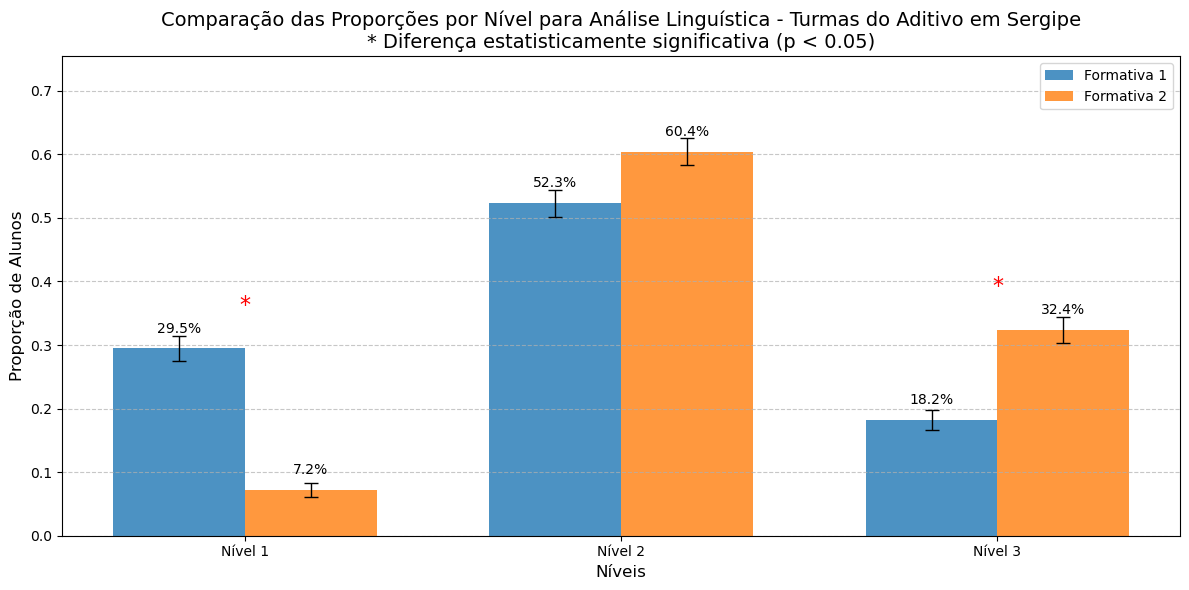

In [19]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_analise_linguistica[f'prop_form_1_{nivel}'] = df_analise_linguistica[f'form_1_{nivel}'] / df_analise_linguistica['total_alunos_form_1']
    df_analise_linguistica[f'prop_form_2_{nivel}'] = df_analise_linguistica[f'form_2_{nivel}'] / df_analise_linguistica['total_alunos_form_2']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA PARA 35 TURMAS NO ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_analise_linguistica[f'prop_form_1_{nivel}'], 
                       df_analise_linguistica[f'prop_form_2_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_analise_linguistica[f'prop_form_2_{nivel}'] - df_analise_linguistica[f'prop_form_1_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA POR MUNICÍPIO ===\n")

for municipio in df_analise_linguistica['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_analise_linguistica[df_analise_linguistica['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_1_{nivel}'], 
                           df_municipio[f'prop_form_2_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_2_{nivel}'] - df_municipio[f'prop_form_1_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA ANÁLISE LINGUÍSTICA (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_1_Nível 1': df_analise_linguistica['form_1_Nível 1'].sum(),
    'form_1_Nível 2': df_analise_linguistica['form_1_Nível 2'].sum(),
    'form_1_Nível 3': df_analise_linguistica['form_1_Nível 3'].sum(),
    'form_2_Nível 1': df_analise_linguistica['form_2_Nível 1'].sum(),
    'form_2_Nível 2': df_analise_linguistica['form_2_Nível 2'].sum(),
    'form_2_Nível 3': df_analise_linguistica['form_2_Nível 3'].sum(),
    'total_form_1': df_analise_linguistica['total_alunos_form_1'].sum(),
    'total_form_2': df_analise_linguistica['total_alunos_form_2'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_2:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_1_Nível 1'], totais_estado['form_1_Nível 2'], totais_estado['form_1_Nível 3']],
    [totais_estado['form_2_Nível 1'], totais_estado['form_2_Nível 2'], totais_estado['form_2_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_1 = [totais_estado['form_1_Nível 1']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 2']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 3']/totais_estado['total_form_1']]

prop_form_2 = [totais_estado['form_2_Nível 1']/totais_estado['total_form_2'],
               totais_estado['form_2_Nível 2']/totais_estado['total_form_2'],
               totais_estado['form_2_Nível 3']/totais_estado['total_form_2']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_1 = [calc_erro_proporcao(p, totais_estado['total_form_1']) for p in prop_form_1]
erro_form_2 = [calc_erro_proporcao(p, totais_estado['total_form_2']) for p in prop_form_2]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', alpha=0.8, color='#1f77b4',
               yerr=erro_form_1, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 2', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_2, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_analise_linguistica[f'prop_form_1_{nivel}'], 
                            df_analise_linguistica[f'prop_form_2_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Análise Linguística - Turmas do Aditivo em Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_1 + prop_form_2) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_22}/teste_wilcoxon_analise_linguistica_aditivo_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()


In [20]:
# Testando Análise Linguística e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_1_Nível 1': group['form_1_Nível 1'].sum(),
            'form_1_Nível 2': group['form_1_Nível 2'].sum(),
            'form_1_Nível 3': group['form_1_Nível 3'].sum(),
            'form_2_Nível 1': group['form_2_Nível 1'].sum(),
            'form_2_Nível 2': group['form_2_Nível 2'].sum(),
            'form_2_Nível 3': group['form_2_Nível 3'].sum(),
            'total_form_1': group['total_alunos_form_1'].sum(),
            'total_form_2': group['total_alunos_form_2'].sum()
        }
        
        # Calcular proporções
        prop_form_1 = [
            totais_municipio['form_1_Nível 1']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 2']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 3']/totais_municipio['total_form_1']
        ]
        
        prop_form_2 = [
            totais_municipio['form_2_Nível 1']/totais_municipio['total_form_2'],
            totais_municipio['form_2_Nível 2']/totais_municipio['total_form_2'],
            totais_municipio['form_2_Nível 3']/totais_municipio['total_form_2']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_1 = [calc_erro(p, totais_municipio['total_form_1']) for p in prop_form_1]
        erro_form_2 = [calc_erro(p, totais_municipio['total_form_2']) for p in prop_form_2]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', color='#1f77b4',
                       yerr=erro_form_1, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 2', color='#ff7f0e',
                       yerr=erro_form_2, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_1_{nivel}'], 
                                        group[f'prop_form_2_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Análise Linguística - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_analise_linguistica_aditivo_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_22, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_analise_linguistica, output_dir_relatorio_22)


Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_Canindé_de_São_Francisco.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_Carira.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_Itabaiana.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_Itabaianinha.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_Nossa_Senhora_do_Socorro.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditi

/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_Simão_Dias.png
Gráfico salvo em: Data_files/graficos_relatorio_2.2_turmas_aditivo/teste_wilcoxon_analise_linguistica_aditivo_São_Cristóvão.png
